<a href="https://colab.research.google.com/github/KayotPoziloy/eeg_studies/blob/main/%D1%8D%D1%8D%D0%B31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Команда "Нейроштучки":** Гурская Юлия P3420, Яхонтов Максим P3420, Фархутдинов Айдар P3420.

Цель работы:
1. Собрать и подключиться установку для измерения альфа-волн
2. Произвести следующие замеры по 5 минут каждый:
	1. закрытые глаза
	2. закрытые глаза и спокойная музыка
	3. закрытые глаза и рок-музыка или бодрый рэп
	4. закрытые глаза и попытки писать осознанные текс на бумаге
3. Обработать полученные данные
4. Построить графики и проанализировать
5. Сформулировать гипотезы и вывод

# **Теория**

**ЭЭГ (электроэнцефалография)** — метод регистрации биоэлектрической активности мозга с помощью электродов, расположенных на коже головы.

### **Основные ритмы ЭЭГ**

**Delta (δ)**: 0.5–4 Гц, сон.

**Theta (θ)**: 4–8 Гц, расслабленность, дремота.

**Alpha (α)**: 8–13 Гц, состояние спокойного бодрствования, особенно при закрытых глазах.

**Beta (β)**: 13–30 Гц, активность, внимание, стресс.

**Gamma (γ)**: >30 Гц, когнитивные процессы.


### **Альфа-ритмы**

Наиболее выражены в затылочной области при закрытых глазах.

Снижаются при умственной активности или сильных сенсорных раздражителях (музыка, чтение, письмо).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch

# **Предобработка данных**

In [ ]:
file_paths = [
    "/content/1_A0.csv",
    "/content/2_A0.csv",
    "/content/3_A0.csv",
    "/content/4_A0.csv"
]

In [ ]:
# Считываем данные
# Создаем словарь для хранения данных
dataframes = {}

# Функция для проверки файла
def get_data(file_path):
    try:
        # Загружаем файл (предполагаем, что разделитель - точка с запятой)
        df = pd.read_csv(file_path, sep = ';')
        return df
    except Exception as e:
        print(f"Ошибка при загрузке файла {file_path}: {e}")
        return None

for i, path in enumerate(file_paths, 1):
    df = get_data(path)
    if df is not None:
        # Сохраняем dataframe
        dataframes[path] = df
# Пример доступа к данным
if len(dataframes) > 0:
    first_key = list(dataframes.keys())[0]
    print(f"\nПример данных из первого файла ({first_key}):")
    print(dataframes[first_key].head())
    print(f"\nТипы данных:")
    print(dataframes[first_key].dtypes)



Пример данных из первого файла (/content/1_A0.csv):
   15.39068699  \t2.68627453
0    15.390687      2.686275
1    15.390687      2.843137
2    15.403000      2.862745
3    15.403000      2.862745
4    15.403000      2.843137

Типы данных:
15.39068699     float64
\t2.68627453    float64
dtype: object


In [ ]:
# Создаем словарь для проверки пропусков в данных
missing_info = {}

# Функция для проверки файла
def check_file_for_missing(df):
  total_missing = df.isnull().sum().sum()
  missing_per_column = df.isnull().sum()
  return total_missing, missing_per_column

# Проверяем все файлы
print("Проверка файлов на пропуски данных:\n")
print("=" * 60)
i = 0
for path, df in dataframes.items():
    i += 1
    total_missing, missing_per_col = check_file_for_missing(df)
    missing_info[path] = {
            'total_missing': total_missing,
            'missing_per_column': missing_per_col,
            'shape': df.shape,
            'columns': df.columns.tolist()
        }
    # Выводим информацию
    exercise_num = i  # Получаем номер упражнения

    print(f"Файл {i}: {exercise_num} упр")
    print(f"  Размер данных: {df.shape}")
    print(f"  Всего пропущенных значений: {total_missing}")

    if total_missing > 0:
        print("  Пропуски по столбцам:")
        for col, missing_count in missing_per_col.items():
          if missing_count > 0:
            print(f"    - {col}: {missing_count} пропусков")
          else:
            print("  ✓ Пропусков нет!")
        print("-" * 40)



Проверка файлов на пропуски данных:

Файл 1: 1 упр
  Размер данных: (99828, 2)
  Всего пропущенных значений: 0
Файл 2: 2 упр
  Размер данных: (101242, 2)
  Всего пропущенных значений: 0
Файл 3: 3 упр
  Размер данных: (98578, 2)
  Всего пропущенных значений: 0
Файл 4: 4 упр
  Размер данных: (99851, 2)
  Всего пропущенных значений: 0


In [ ]:
# Переименовываем столбцы во всех датафреймах
for path, df in dataframes.items():
    # Проверяем количество столбцов
    if len(df.columns) >= 2:
        # Переименовываем первые два столбца
        new_columns = ['time', 'voltage']
        df.columns = new_columns
    else:
        print(f"В файле {path} меньше 2 столбцов")

In [ ]:
# Для каждого датафрейма устанавливаем первую точку времени как 0
for path, df in dataframes.items():
    if 'time' in df.columns and len(df) > 0:
        # Находим первое значение времени
        first_time = df['time'].iloc[0]
        # Вычитаем его из всего столбца времени
        df['time'] = (df['time'] - first_time)
dataframes
# # Проверим результат на примере первого файла
# df1 = dataframes['/content/1_A0.csv']
# print("Время после нормализации (первая точка = 0):")
# print(df1['time'].head(10))

{'/content/1_A0.csv':              time   voltage
 0        0.000000  2.686275
 1        0.000000  2.843137
 2        0.012313  2.862745
 3        0.012313  2.862745
 4        0.012313  2.843137
 ...           ...       ...
 99823  306.018676  2.019608
 99824  306.018676  2.117647
 99825  306.018676  2.196079
 99826  306.026763  2.294118
 99827  306.026763  2.490196
 
 [99828 rows x 2 columns],
 '/content/2_A0.csv':               time   voltage
 0         0.000000  4.607843
 1         0.000000  4.372549
 2         0.000000  4.352941
 3         0.012280  4.235294
 4         0.012280  4.313725
 ...            ...       ...
 101237  310.393779  2.921569
 101238  310.406047  2.980392
 101239  310.406047  2.960784
 101240  310.406047  2.901961
 101241  310.406047  2.960784
 
 [101242 rows x 2 columns],
 '/content/3_A0.csv':              time   voltage
 0        0.000000  1.313725
 1        0.000000  1.372549
 2        0.000000  1.725490
 3        0.012329  1.823529
 4        0.012329  2.215

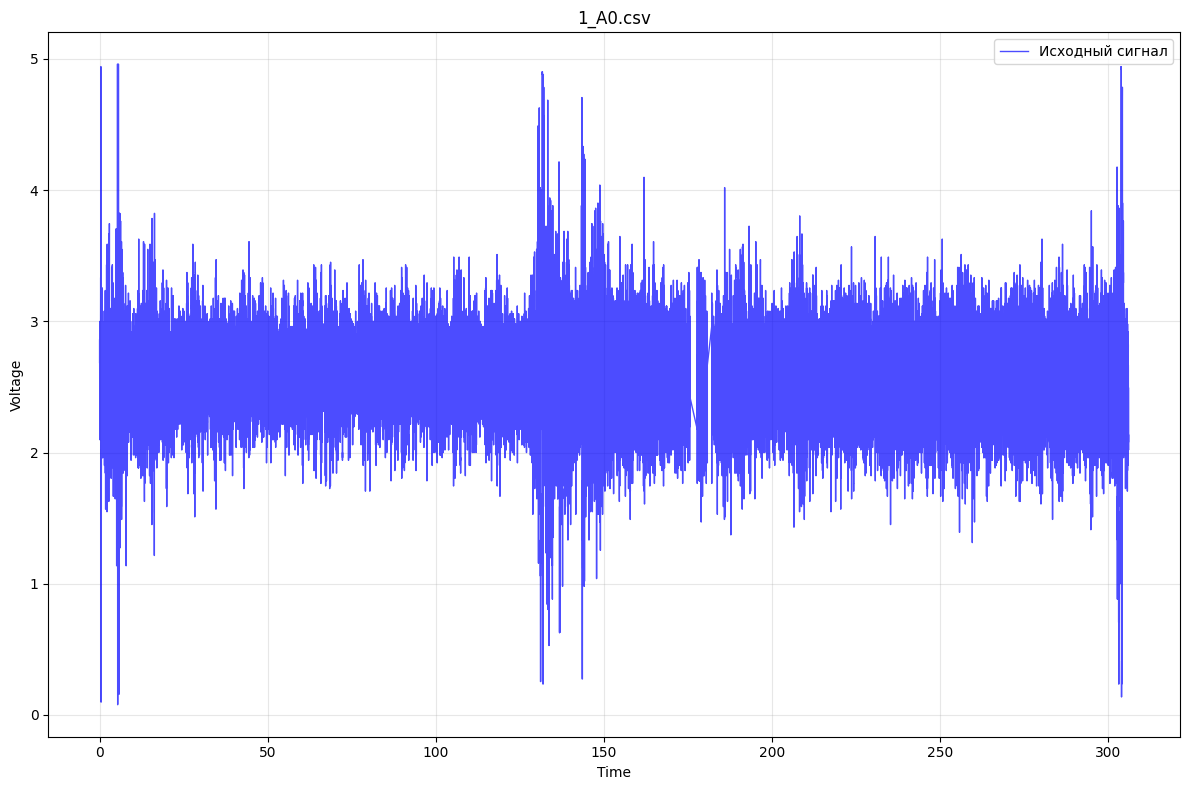

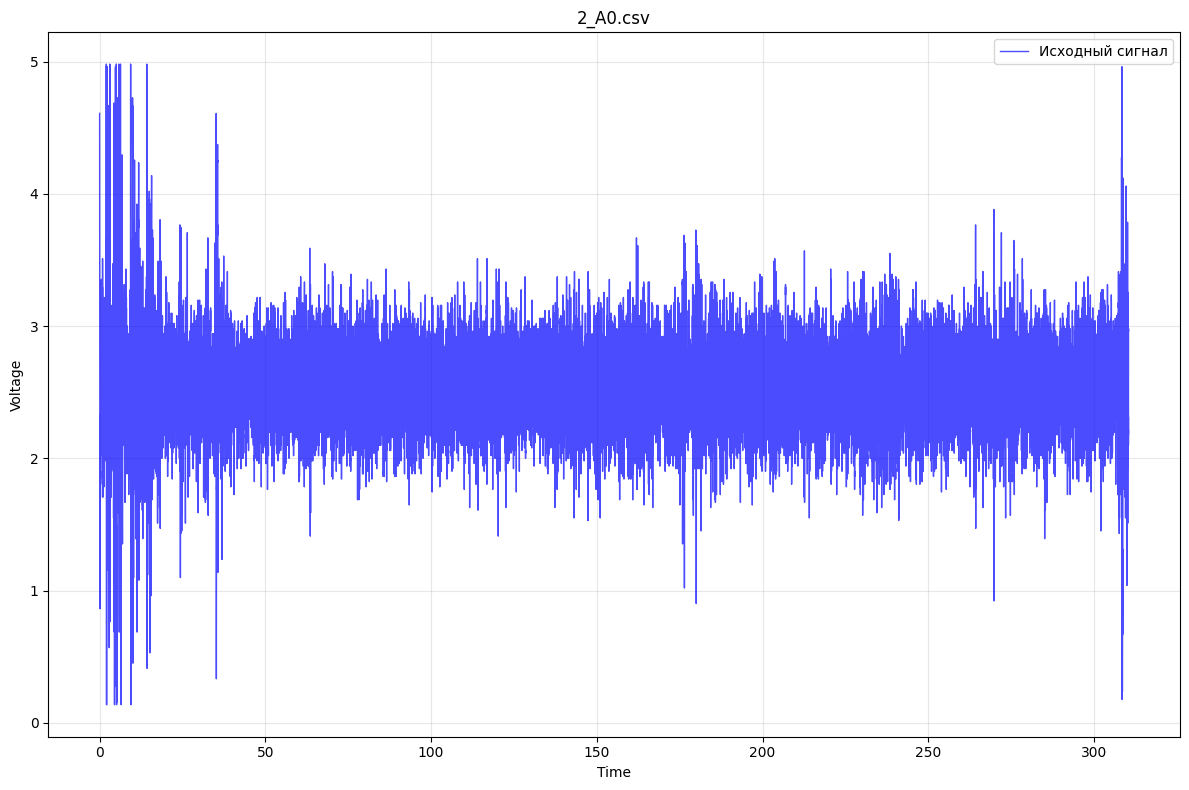

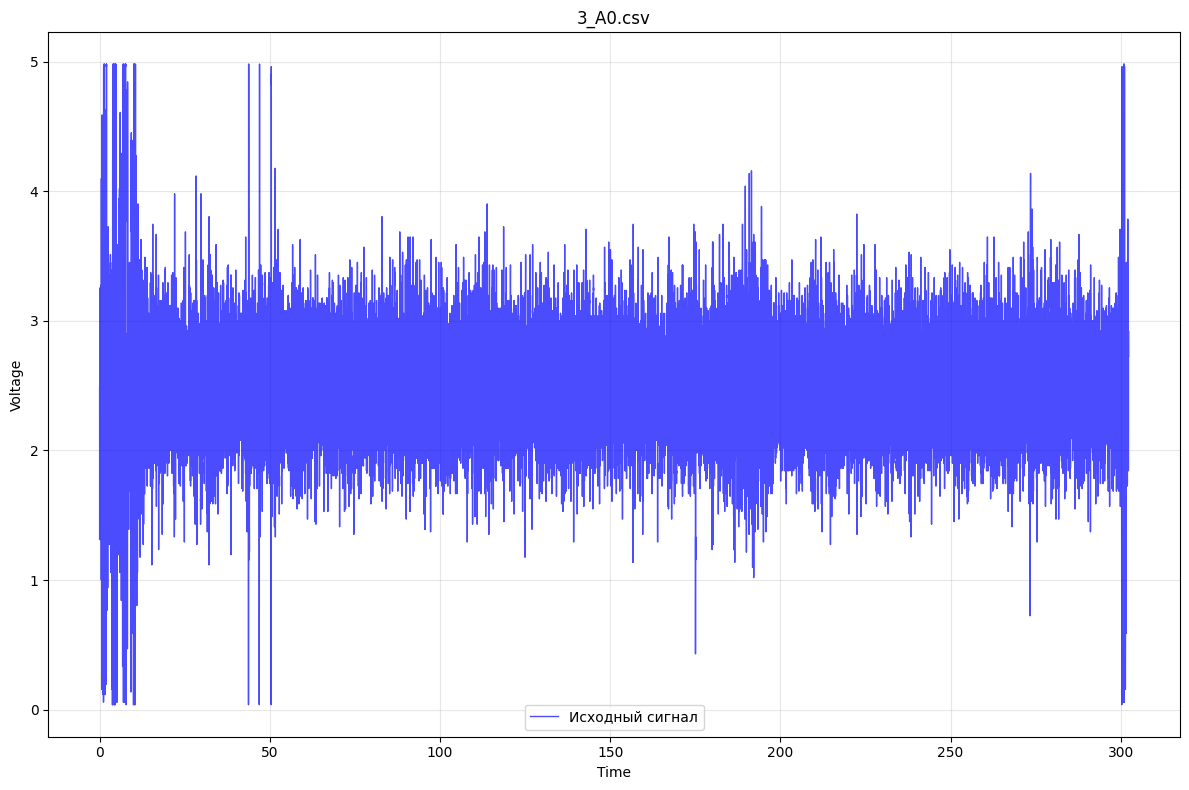

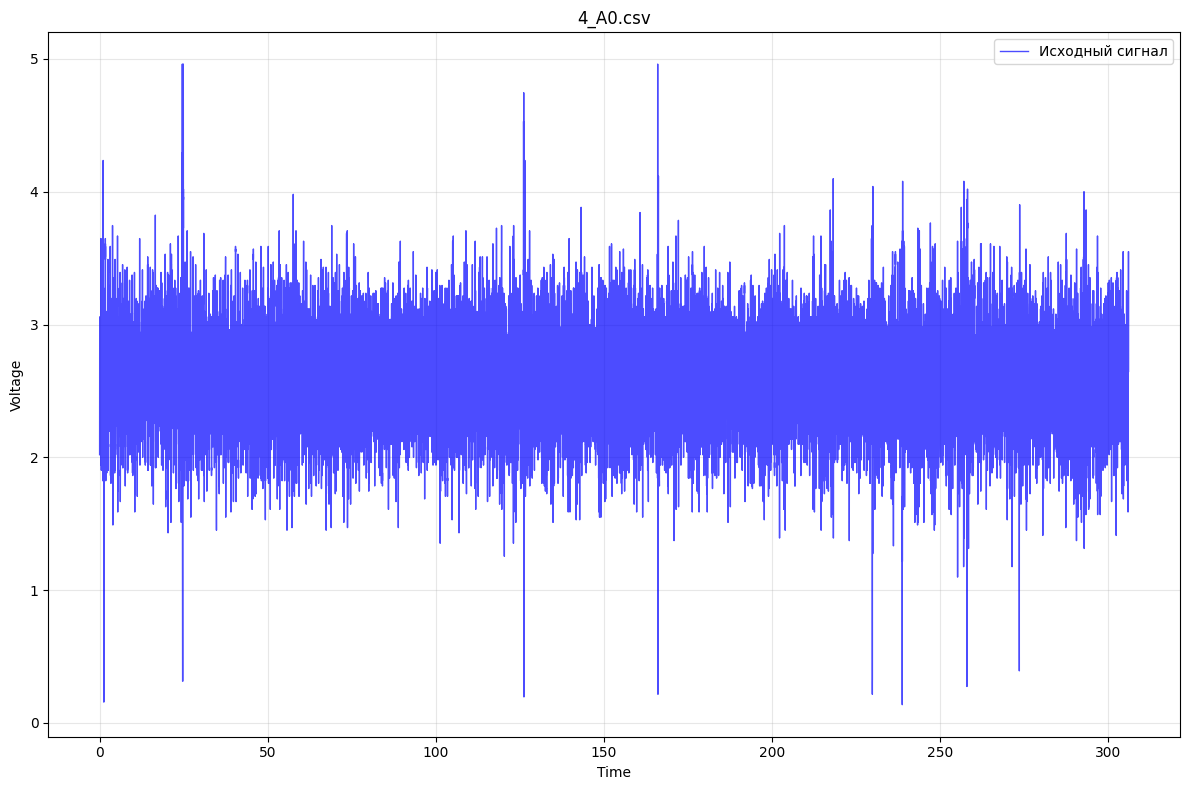

In [ ]:
# Визуализация исходных данных (с учетом проверки пропусков, подписания столбцов)
for path, df in dataframes.items():
    filename = path.split('/')[-1]
    if 'voltage' not in df.columns:
        print(f"В файле {filename} нет столбца voltage")
        continue

    plt.figure(figsize=(12, 8))
    plt.plot(df['time'], df['voltage'], 'blue', alpha=0.7, label='Исходный сигнал', linewidth=1)
    plt.title(f'{filename}')
    plt.xlabel('Time')
    plt.ylabel('Voltage')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Построим график для 10-секундного фрагмента каждой записи

Длительность записи: 306.02676296 секунд
Середина: 153.01338148 секунд


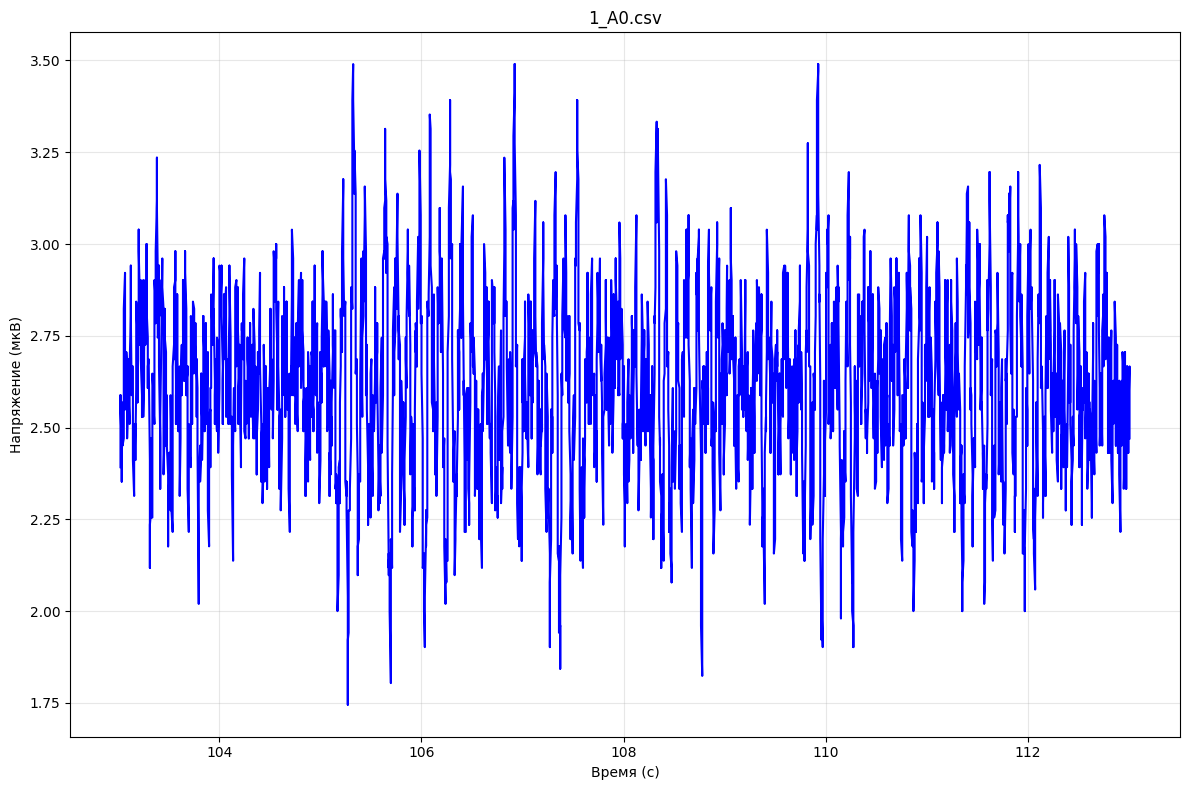

Длительность записи: 310.40604687 секунд
Середина: 155.203023435 секунд


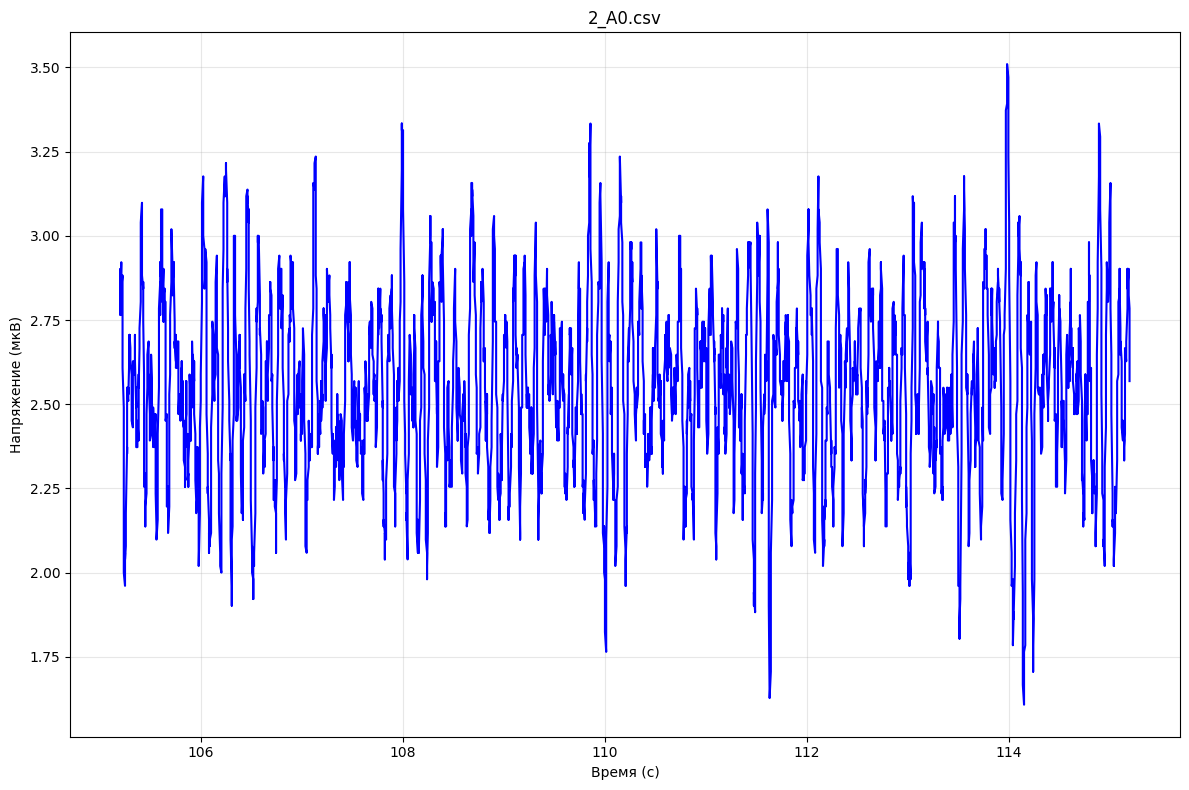

Длительность записи: 302.2910614 секунд
Середина: 151.1455307 секунд


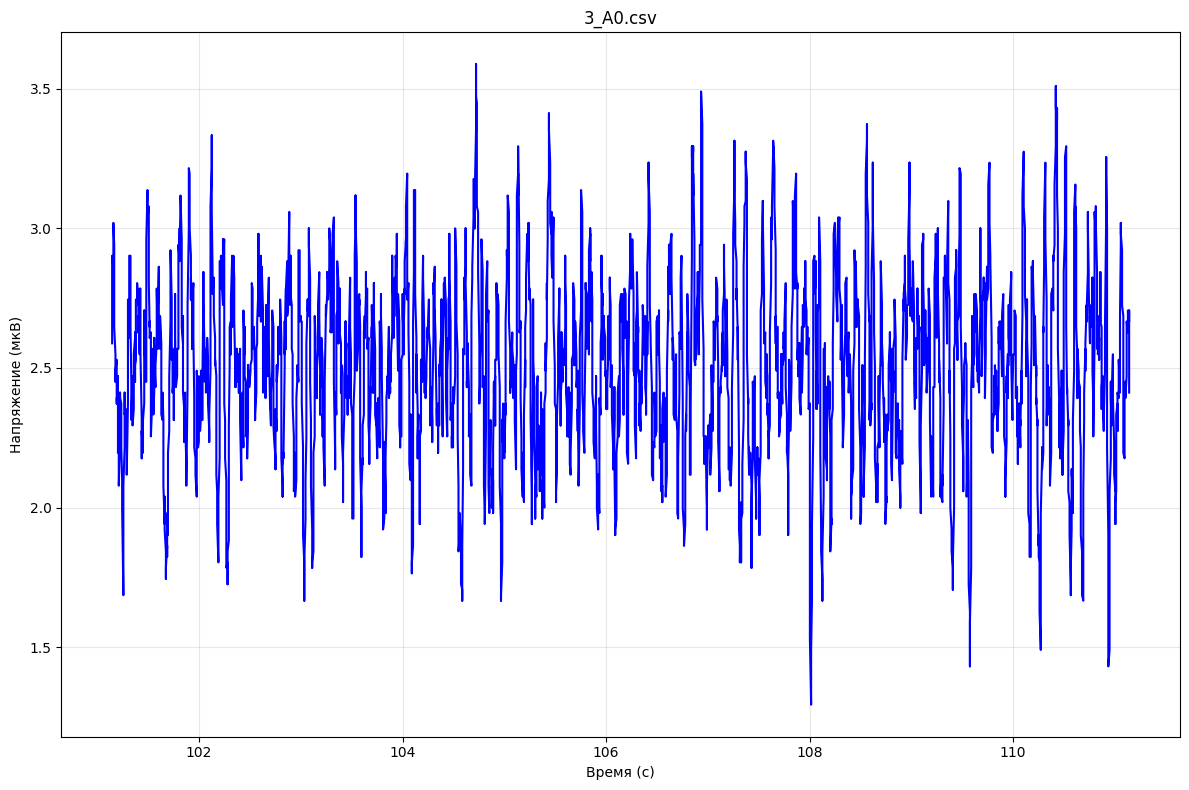

Длительность записи: 306.16244077 секунд
Середина: 153.081220385 секунд


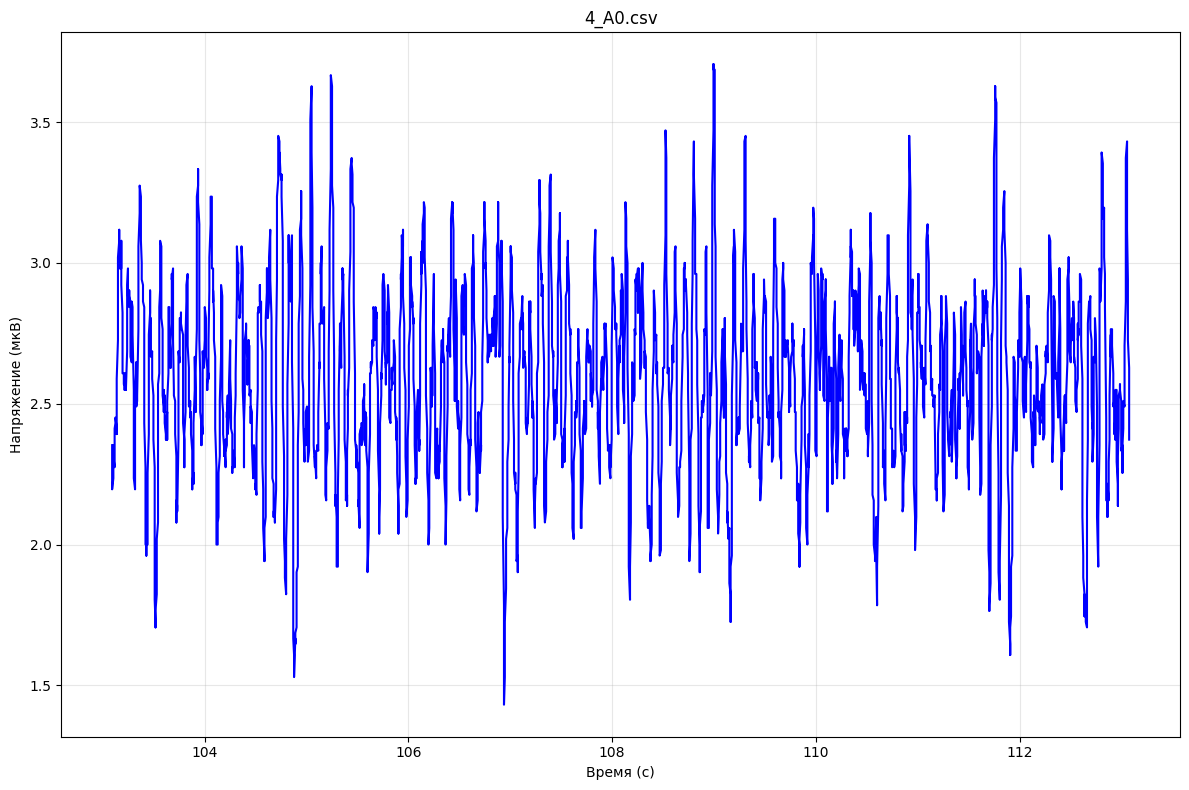

In [ ]:
for path, df in dataframes.items():
  filename = path.split('/')[-1]

  # Общая длительность записи
  total_time = df['time'].iloc[-1]
  print("Длительность записи:", total_time, "секунд")

  # Время середины
  mid_time = total_time / 2
  print("Середина:", mid_time, "секунд")

  # Берем 10 секунд вокруг середины
  start = mid_time - 50
  end = mid_time - 40
  fragment = df[(df['time'] >= start) & (df['time'] <= end)]

  plt.figure(figsize=(12, 8))
  plt.plot(fragment['time'], fragment['voltage'], color='blue')
  plt.title(f'{filename}')
  plt.xlabel("Время (с)")
  plt.ylabel("Напряжение (мкВ)")
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()



Убираем низкочастотный дрейф и шумы (фильтр 1-40гц)

- медленные колебания (0–0.5 Гц) — это не активность мозга, а дрейф электрода, дыхание, движение головы и т.п.

- высокочастотные шумы (>40–50 Гц) — это электросеть (50/60 Гц), артефакты мышц, наушников и др.

1_A0.csv → Частота дискретизации: 326.20 Гц


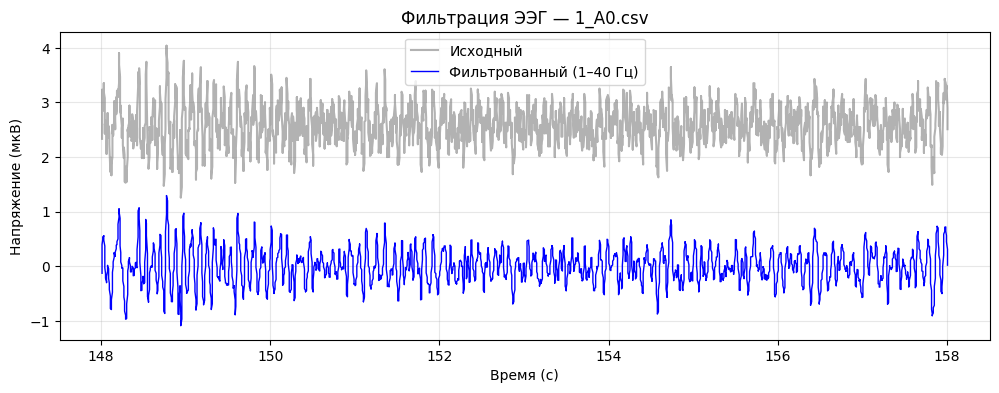

2_A0.csv → Частота дискретизации: 326.16 Гц


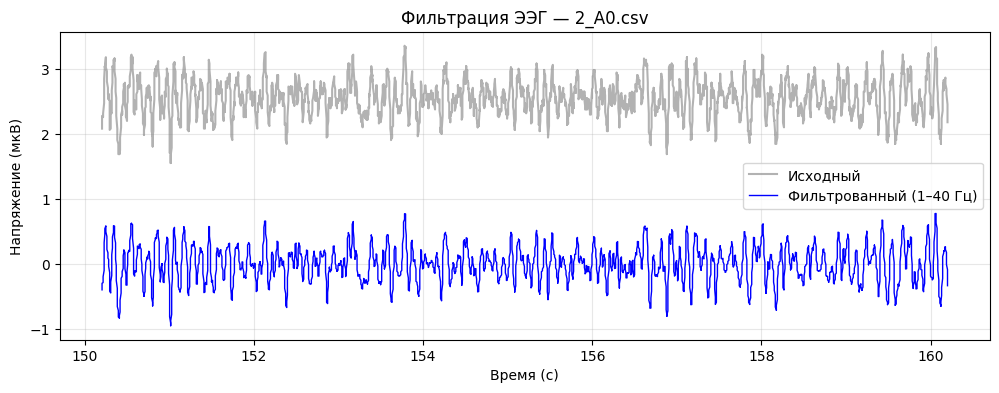

3_A0.csv → Частота дискретизации: 326.10 Гц


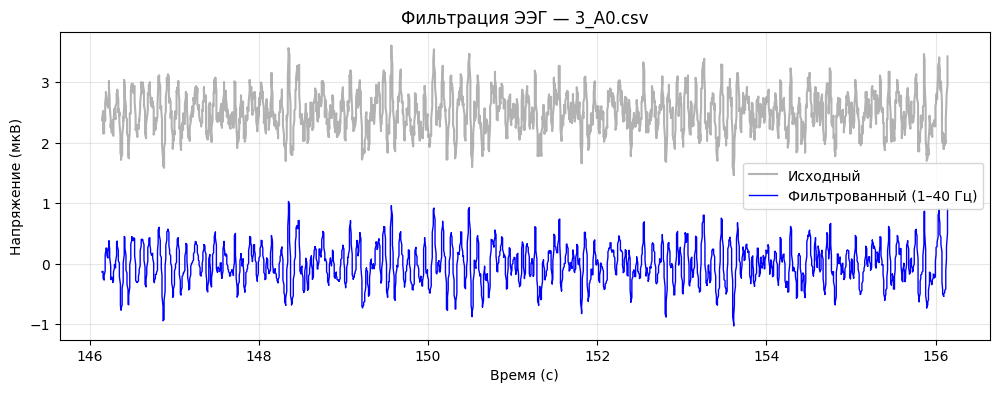

4_A0.csv → Частота дискретизации: 326.13 Гц


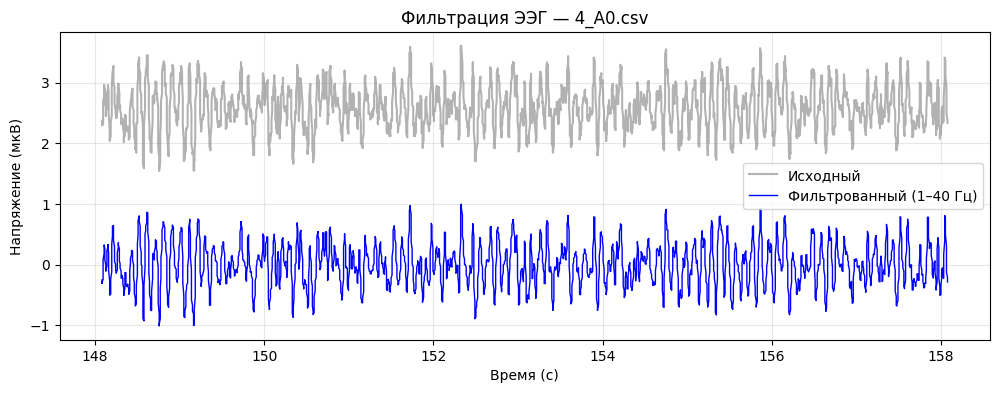

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

for path, df in dataframes.items():
    filename = path.split('/')[-1]

    # Частота дискретизации
    dt = np.mean(np.diff(df['time']))
    fs = 1 / dt
    print(f"{filename} → Частота дискретизации: {fs:.2f} Гц")

    # Фильтруем сигнал (1–40 Гц)
    filtered = bandpass_filter(df['voltage'], 1, 40, fs)

    # Берем 10 секунд вокруг середины записи
    total_time = df['time'].iloc[-1]
    mid_time = total_time / 2
    start = mid_time - 5
    end = mid_time + 5
    fragment = df[(df['time'] >= start) & (df['time'] <= end)]
    fragment_filtered = filtered[(df['time'] >= start) & (df['time'] <= end)]

    # Сравнение: исходный и фильтрованный сигнал (фрагмент)
    plt.figure(figsize=(12, 4))
    plt.plot(fragment['time'], fragment['voltage'], 'gray', alpha=0.6, label="Исходный")
    plt.plot(fragment['time'], fragment_filtered, 'blue', lw=1, label="Фильтрованный (1–40 Гц)")
    plt.title(f"Фильтрация ЭЭГ — {filename}")
    plt.xlabel("Время (с)")
    plt.ylabel("Напряжение (мкВ)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


**Альфа-ритм** занимает диапазон 8-13гц.
**Спектральный анализ** раскладывает сигнал на частоты и показывает, какая мощность приходится на каждую частоту.

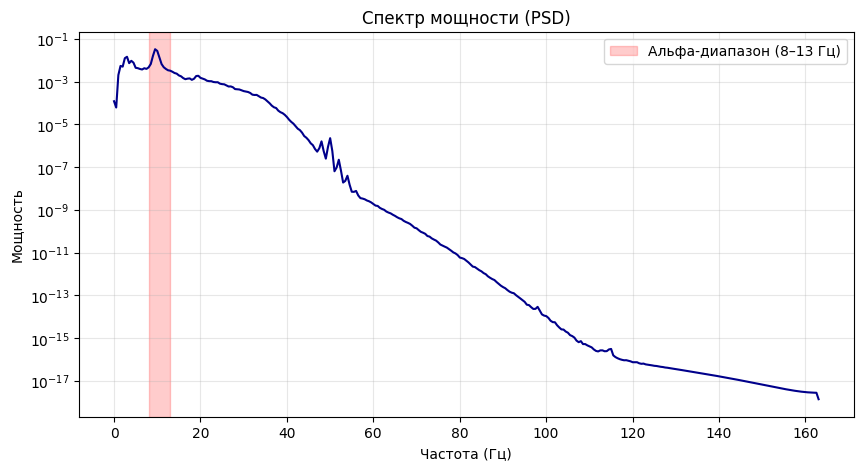

In [ ]:
from scipy.signal import welch

freqs, psd = welch(filtered, fs, nperseg=fs*2)

plt.figure(figsize=(10, 5))
plt.semilogy(freqs, psd, color='darkblue')
plt.axvspan(8, 13, color='red', alpha=0.2, label="Альфа-диапазон (8–13 Гц)")
plt.title("Спектр мощности (PSD)")
plt.xlabel("Частота (Гц)")
plt.ylabel("Мощность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


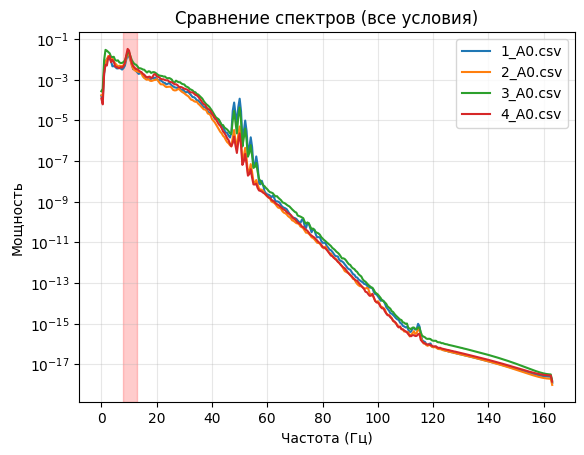

In [ ]:
for path, df in dataframes.items():
    dt = np.mean(np.diff(df['time']))
    fs = 1 / dt
    sig = bandpass_filter(df['voltage'], 1, 40, fs)
    freqs, psd = welch(sig, fs, nperseg=fs*2)

    filename = path.split("/")[-1]
    plt.semilogy(freqs, psd, label=filename)

plt.axvspan(8, 13, color='red', alpha=0.2)
plt.title("Сравнение спектров (все условия)")
plt.xlabel("Частота (Гц)")
plt.ylabel("Мощность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Ожидалось, что сенсомоторные раздражители (музыка, письмо) будут снижать активность альфа-каналов, но по графикам наглядно видно, что все 4 замера имеют примерно одинаковую мощность в альфа-канале.

Возможные объяснения:
1. Альфа-ритм возникает при закрытых глазах, даже если человека слушает музыку или пишет, альфа-ритм в затылочной области сохраняется, хотя и должен частично подавляться.
2. У разных людей альфа-ритм может быть выражен сильнее, даже при активности он может оставаться заметным в затылочной области, особенно, если мозг не перегружен.


Проведем сухой анализ и сравнение кодом:
1. Среднее напряжение
2. Стд отклонение
3. Средняя мощность α
4. Макс мощность α
5. Частота пика α
6. Доля α

In [ ]:
# Функция фильтра полосовой
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Функция для вычисления средней мощности альфа
def alpha_power(psd, freqs, alpha_band=(8, 13)):
    idx = np.logical_and(freqs >= alpha_band[0], freqs <= alpha_band[1])
    return np.mean(psd[idx])

# Словарь для результатов
results = []

experiments = ['закрытые глаза',
               'закрытые глаза и спокойная музыка',
               'закрытые глаза и рок-музыка',
               'закрытые глаза и письмо ручкой']
i = 0

for path, df in dataframes.items():
    # Частота дискретизации
    dt = np.mean(np.diff(df['time']))
    fs = 1 / dt

    # Фильтрация сигнала 1-40 Гц
    sig = bandpass_filter(df['voltage'], 1, 40, fs)

    # PSD
    freqs, psd = welch(sig, fs, nperseg=fs*2)

    # Метрики
    mean_voltage = np.mean(sig)
    std_voltage = np.std(sig)
    alpha_avg = alpha_power(psd, freqs)
    idx_alpha = np.logical_and(freqs >= 8, freqs <= 13)
    alpha_max = np.max(psd[idx_alpha])
    alpha_peak_freq = freqs[idx_alpha][np.argmax(psd[idx_alpha])]
    alpha_ratio = np.sum(psd[idx_alpha]) / np.sum(psd)

    # Сохраняем результат
    results.append({
        'Эксперимент': experiments[i],
        'Среднее напряжение': mean_voltage,
        'Стд отклонение': std_voltage,
        'Средняя мощность α': alpha_avg,
        'Макс мощность α': alpha_max,
        'Частота пика α (Гц)': alpha_peak_freq,
        'Доля α': alpha_ratio
    })

    i += 1

# Создаём DataFrame для красивой таблицы
results_df = pd.DataFrame(results)
results_df = results_df.round(4)  # округляем для отчета
print(results_df)


                         Эксперимент  Среднее напряжение  Стд отклонение  \
0                     закрытые глаза             -0.0001          0.3077   
1  закрытые глаза и спокойная музыка             -0.0007          0.3397   
2        закрытые глаза и рок-музыка              0.0003          0.4331   
3     закрытые глаза и письмо ручкой              0.0003          0.3539   

   Средняя мощность α  Макс мощность α  Частота пика α (Гц)  Доля α  
0              0.0072           0.0160               9.5059  0.3821  
1              0.0085           0.0195               9.5046  0.3757  
2              0.0116           0.0226              10.0031  0.3064  
3              0.0118           0.0324               9.5039  0.4690  


# Интерпретация данных

**Средняя мощность α (8–13 Гц)**

- Самая низкая в 1_A0.csv (закрытые глаза, без музыки): 0.0072
- Чуть выше в 2_A0.csv (спокойная музыка): 0.0085
- Выше в 3_A0.csv (рок/рэп): 0.0116
- Самая высокая в 4_A0.csv (письмо): 0.0118

> Видно, что амплитуда α-ритма немного увеличивается с активностью, это может быть связано с артефактами или индивидуальной реакцией.

**Максимальная мощность α и частота пика**

- Частота пика альфа почти одинаковая (~9.5–10 Гц) во всех условиях.
- Максимальная мощность α растёт в опытах 3 и 4.

> Это говорит, что альфа-ритм сохраняется на тех же частотах, но его выраженность (амплитуда) зависит от активности и стимулов.

**Доля α относительно всего сигнала**

- Наибольшая доля α в 4_A0.csv (0.4690) — письмо
- Меньше всего в 3_A0.csv (0.3064) — рок/рэп
- Для первых двух опытов доля около 0.38

> Доля α показывает, какая часть энергии сигнала приходится на альфа-диапазон.
- Спокойная музыка немного снижает долю α (0.3757 vs 0.3821).
- Рок/рэп сильно снижает долю α (0.3064) — подавление альфа при сильной стимуляции.
- Письмо — доля α растёт (0.4690), возможно из-за фокусировки на задаче и медитативности задачи.

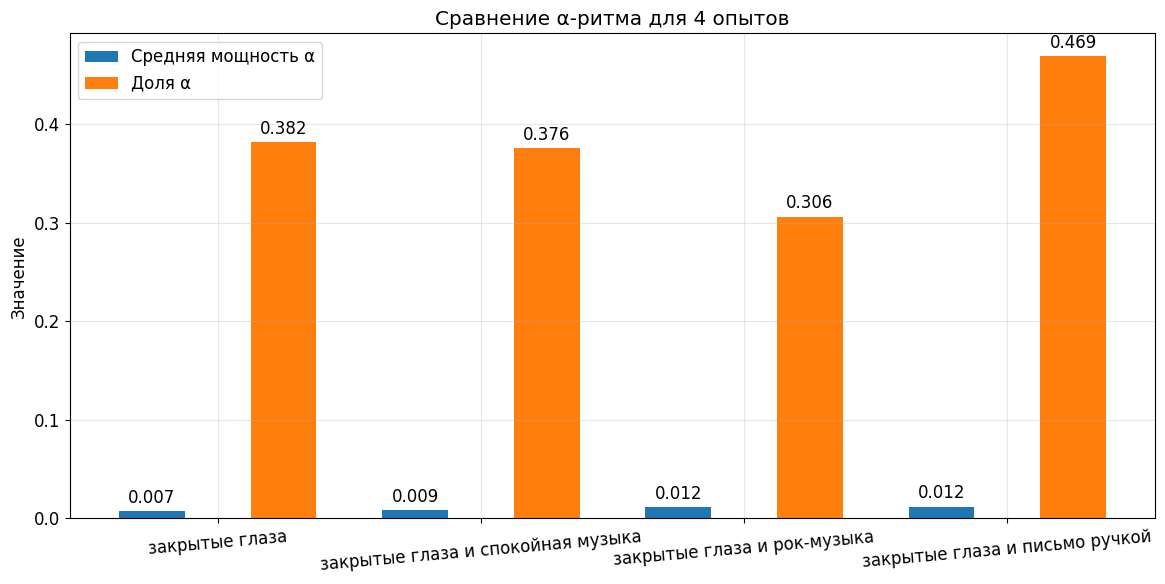

In [ ]:
# Данные из таблицы
alpha_avg = results_df['Средняя мощность α'].values
alpha_ratio = results_df['Доля α'].values

x = np.arange(4)
width = 0.25  # ширина столбцов

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, alpha_avg, width, label='Средняя мощность α')
rects2 = ax.bar(x + width, alpha_ratio, width, label='Доля α')

# Подписи и оформление
ax.set_ylabel('Значение')
ax.set_title('Сравнение α-ритма для 4 опытов')
ax.set_xticks(x)
ax.set_xticklabels(experiments, rotation=5)
ax.legend()
ax.grid(alpha=0.3)

# Подписи значений над столбцами
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


# Вывод

При прослушивании музыки прослеживается небольшое снижение доли альфа-ритмов, особенно при прослушивании энергичной музыки. Письмо с закрытыми глазами увеличиает долю альфа-ритмов, возможно из-за концентрации на задачи и медитативности. Это говорит о том, что при фокусировании усиливаются альфа-волны.
